## 1. Aplica la estandarizacion de las variables utilizando  StandardScaler

In [3]:

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# cargamos los datos
diabetes = load_diabetes()

# guardamos las variables del dataset en X
X = diabetes.data

# creamos el objeto para estandarizar los datos
scaler = StandardScaler()

# estandarizamos las variables
X_scaled = scaler.fit_transform(X)
# comparamos ambos
print(X[:5])
print("Datos estandarizados:")
print(X_scaled[:5])


[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
Datos estandarizados:
[[ 0.80050009  1.06548848  1.29708846  0.45984057 -0.92974581 -0.73206462
  -0.91245053 -0.05449919  0.41853093 -0.37098854]
 [-0.03956713 -0.93853666 -1.08218016 -0.55350458 -0.17762425 -0.40288615
   1.56441355 -0.83030083 -1.43658851 -1.93847913]
 [ 1.79330681  1.06548848  0.93453324 -0.1192138  -0.95867356 -0.71889748
  -0.68024452 -0.05449919  0

## 2. Aplica PCA de forma que se preserve al menos el 80% de la varianza total del conjunto de datos. ¿Cuál es el número de componentes principales obtenidos?

In [9]:
from sklearn.decomposition import PCA

# aplicamos PCA conservando al menos el 80% de la varianza
pca = PCA(n_components=0.80)

# ajustamos PCA a los datos estandarizados
X_reduced = pca.fit_transform(X_scaled)

print("Numero de componentes principales: ", pca.n_components_)

Numero de componentes principales:  5


## 3. Haz una comparacion del tamaño aproximado en memoria del dataset original y del dataser reducido (en kilobytes).

In [10]:
# obntenemos el tamaño del arreglo, con .nbyte y lo pasamos a kilobytes dividiendo entre 1024
tamaño_original = X_scaled.nbytes / 1024
tamaño_reducido = X_reduced.nbytes / 1024

print("Tamaño original:", tamaño_original, "KB")
print("Tamaño reducido:", tamaño_reducido, "KB")

Tamaño original: 34.53125 KB
Tamaño reducido: 17.265625 KB


## 4. Proyecta los datos estandarizado al espacio reducido y luego reconstruye una aproximacion usando: 

In [14]:
X_reduced = pca.transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_reduced)
print("X_reduced:", X_reduced.shape)
print("X_reconstructed:", X_reconstructed.shape)

X_reduced: (442, 5)
X_reconstructed: (442, 10)


## 5. Calcula el error de reconstruccion utilizando:

In [17]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(X_scaled, X_reconstructed)
print("Error de reconstrucción:", MSE)

Error de reconstrucción: 0.16598455185932298


## 6. Calcula el MSE para k = 1, 2, . . . , 10 componentes y grafica el MSE en funcion de k (lo que se llama curva de error de reconstruccion en PCA).A partir de que numero de componentes el error deja de disminuir significativamente?

Componentes: 1 MSE: 0.5975789249847214
Componentes: 2 MSE: 0.448346957224852
Componentes: 3 MSE: 0.32775033131235165
Componentes: 4 MSE: 0.2322026909859404
Componentes: 5 MSE: 0.16598455185932298
Componentes: 6 MSE: 0.10571284429731045
Componentes: 7 MSE: 0.052056279065372676
Componentes: 8 MSE: 0.008688075428814277
Componentes: 9 MSE: 0.000856072982705297
Componentes: 10 MSE: 1.0116481678042892e-30


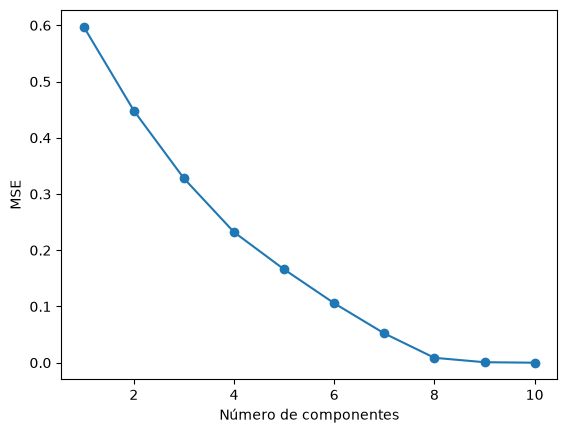

In [24]:
import matplotlib.pyplot as plt
errores = []

for k in range(1,11):
    pca_k = PCA(n_components=k)

    X_reduced_k = pca_k.fit_transform(X_scaled)
    X_reconstructed_k = pca_k.inverse_transform(X_reduced_k)

    mse_k = mean_squared_error(X_scaled, X_reconstructed_k)
    errores.append(mse_k)

    print("Componentes:", k, "MSE:", mse_k)

plt.plot(componentes, errores, marker='o')
plt.xlabel("Número de componentes")
plt.ylabel("MSE")
plt.show()

En la grafica observamos que apartir de 8 componentes el error ya es muy pequeño y la curva comienza a estabilizarse , y la diferencia con respecto de los siguientes numeros de componentes es menor,